# Charon's tidal k2/Q from the Pluto-Charon impact to today

Scratch work. The question: what is Charon's effective tidal quality factor Q right after the giant impact, when the injected heat brought its ice shell to the melting point, and what is it today, after the shell has cooled for about 4.5 billion years?

The approach: model Charon as a rocky core under a water-ice shell, cool the shell from the melting point, and at each time compute the degree-2 Love number k2 with TidalPy's radial solver, using a temperature-dependent ice viscosity. Then k2/Q = -Im(k2), the quantity that sets tidal dissipation, and Q = |k2| / |Im(k2)|.

In [1]:
%matplotlib inline
# This notebook sits in the repository root, where Python would import the uncompiled TidalPy source tree
# instead of the installed package, so the notebook folder is dropped from the import path first.
import os
import sys

_notebook_dir = os.path.abspath(os.getcwd())
sys.path = [path for path in sys.path if path not in ('', '.') and os.path.abspath(path) != _notebook_dir]

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import diags

from TidalPy.constants import year as YEAR
from TidalPy.RadialSolver_x import radial_solver
from TidalPy.radiogenics_x import IsotopeRadiogenics
from TidalPy.rheology_x import Andrade, Maxwell
from TidalPy.viscosity_x import make_viscosity

MYR = 1.0e6 * YEAR

C:\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:55: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


## Structure

New Horizons measured Charon's radius (606 km) and mass (1.586e21 kg), a mean density of about 1700 kg/m3. Two layers reproduce both: hydrated rock at 2700 kg/m3 under water ice at 950 kg/m3. The core radius follows from the mass. The forcing frequency is Charon's orbital mean motion (period 6.387 days), the frequency of eccentricity tides in the synchronous orbit.

In [2]:
RADIUS = 606.0e3                            # [m]
MASS = 1.586e21                             # [kg]
FREQUENCY = 2.0 * np.pi / (6.3872 * 86400.0)  # Orbital mean motion [rad/s]

RHO_ICE = 950.0                             # [kg/m3]
RHO_CORE = 2700.0                           # [kg/m3]
VOLUME = 4.0 / 3.0 * np.pi * RADIUS**3
R_CORE = ((MASS - RHO_ICE * VOLUME) / (RHO_CORE - RHO_ICE) / (4.0 / 3.0 * np.pi)) ** (1.0 / 3.0)
M_CORE = RHO_CORE * 4.0 / 3.0 * np.pi * R_CORE**3
print(f"core radius {R_CORE / 1e3:.0f} km, ice shell {(RADIUS - R_CORE) / 1e3:.0f} km thick, "
      f"core mass {M_CORE:.3e} kg, forcing frequency {FREQUENCY:.3e} rad/s")

core radius 457 km, ice shell 149 km thick, core mass 1.081e+21 kg, forcing frequency 1.139e-05 rad/s


## Cooling the ice shell

Assumptions, all simple on purpose:

- The impact left the whole ice shell at the melting point, 270 K (the melting point at the roughly 40 MPa pressure of the shell's base), 100 Myr after the solar system formed.
- Heat leaves by conduction only, with the conductivity of ice k = 567/T W/m/K and heat capacity c = 185 + 7.037 T J/kg/K, to a surface held at 50 K.
- Heat enters at the base from radioactive decay in a chondritic core (TidalPy's `modern_day_chondritic` isotopes). The core's own stored heat is ignored, and so is the latent heat of melting: a shell node that reaches the melting point is simply held there. The run is repeated without the core heating to show how much it matters.

In [3]:
T_SURFACE = 50.0     # [K]
T_MELT = 270.0       # [K]
NODES = 121

radiogenics = IsotopeRadiogenics.from_dataset("modern_day_chondritic")   # quoted at 4600 Myr, today
AGE_TODAY = radiogenics.ref_time
T_IMPACT = 100.0 * MYR
DURATION = AGE_TODAY - T_IMPACT

r = np.linspace(R_CORE, RADIUS, NODES)       # Shell nodes from the core boundary to the surface [m]
dr = r[1] - r[0]
r_face = 0.5 * (r[:-1] + r[1:])
node_volume = 4.0 / 3.0 * np.pi * (r_face**3 - np.concatenate([[R_CORE], r_face[:-1]])**3)
area_face = 4.0 * np.pi * r_face**2
TIMES = np.concatenate([[0.0], np.logspace(np.log10(1.0e3 * YEAR), np.log10(DURATION), 80)])


def cool_shell(core_heating):
    """Temperature of every shell node [K] at TIMES, shaped (node, time), from an isothermal start at T_MELT."""
    def derivatives(t, interior):
        temperature = np.append(interior, T_SURFACE)
        k_face = 567.0 / (0.5 * (temperature[:-1] + temperature[1:]))
        power_out = -area_face * k_face * (temperature[1:] - temperature[:-1]) / dr
        basal = radiogenics.calc_heating(T_IMPACT + t, M_CORE) if core_heating else 0.0
        power_in = np.concatenate([[basal], power_out[:-1]])
        rate = (power_in - power_out) / (RHO_ICE * (185.0 + 7.037 * interior) * node_volume)
        return np.where((interior >= T_MELT) & (rate > 0.0), 0.0, rate)

    sparsity = diags([1.0, 1.0, 1.0], [-1, 0, 1], shape=(NODES - 1, NODES - 1))
    solution = solve_ivp(derivatives, (0.0, DURATION), np.full(NODES - 1, T_MELT), method="BDF",
                         t_eval=TIMES, jac_sparsity=sparsity, rtol=1.0e-6, atol=1.0e-3)
    assert solution.success, solution.message
    return np.vstack([solution.y, np.full(TIMES.size, T_SURFACE)])


shell_temperature = {"with core heating": cool_shell(True), "without core heating": cool_shell(False)}
for case, temperature in shell_temperature.items():
    print(case)
    for years in (0.0, 1e6, 1e7, 1e8, 1e9, 2e9, DURATION / YEAR):
        i = np.argmin(np.abs(TIMES / YEAR - years))
        mean = np.sum(temperature[:-1, i] * node_volume) / np.sum(node_volume)
        print(f"  {TIMES[i] / YEAR:9.2e} yr after the impact: base {temperature[0, i]:5.1f} K, "
              f"shell mean {mean:5.1f} K")

with core heating
   0.00e+00 yr after the impact: base 270.0 K, shell mean 270.0 K
   1.08e+06 yr after the impact: base 270.0 K, shell mean 248.3 K
   9.08e+06 yr after the impact: base 270.0 K, shell mean 206.2 K
   9.31e+07 yr after the impact: base 270.0 K, shell mean 113.4 K
   9.54e+08 yr after the impact: base 270.0 K, shell mean 112.0 K
   2.07e+09 yr after the impact: base 168.4 K, shell mean  87.5 K
   4.50e+09 yr after the impact: base  76.4 K, shell mean  59.9 K
without core heating
   0.00e+00 yr after the impact: base 270.0 K, shell mean 270.0 K
   1.08e+06 yr after the impact: base 270.0 K, shell mean 248.3 K
   9.08e+06 yr after the impact: base 270.0 K, shell mean 206.2 K
   9.31e+07 yr after the impact: base  94.0 K, shell mean  71.7 K
   9.54e+08 yr after the impact: base  50.0 K, shell mean  50.0 K
   2.07e+09 yr after the impact: base  50.0 K, shell mean  50.0 K
   4.50e+09 yr after the impact: base  50.0 K, shell mean  50.0 K


## Tidal response

Ice viscosity follows an Arrhenius law anchored at 1e14 Pa s at the melting point with an activation energy of 50 kJ/mol (diffusion creep); the shear modulus is 3.5 GPa. Two rheologies bracket the behavior: Maxwell, and Andrade (alpha = 0.3, zeta = 1), which adds a transient creep term that dissipates more when the ice is cold. The rock core is a Maxwell solid with shear modulus 40 GPa and viscosity 1e22 Pa s. Each shell node gets the complex moduli of its own temperature, so a cold, elastic lid over a warm base is resolved.

In [4]:
MU_ICE, K_ICE = 3.5e9, 9.0e9
ETA_MELT = 1.0e14
E_ICE = 5.0e4
MU_CORE, K_CORE, ETA_CORE = 40.0e9, 60.0e9, 1.0e22
CORE_SLICES = 40
RHEOLOGIES = {"Maxwell": Maxwell(), "Andrade": Andrade(alpha=0.3, zeta=1.0)}


def love_k2(temperature, rheology, eta_melt=ETA_MELT, eta_core=ETA_CORE, elastic_ice=False):
    """Complex k2 at FREQUENCY for one shell temperature profile [K] (one value per shell node)."""
    ice_viscosity = make_viscosity("reference", {"reference_viscosity_pas": eta_melt,
                                                 "reference_temperature_k": T_MELT,
                                                 "molar_activation_energy_j_mol": E_ICE})
    radius = np.concatenate([np.linspace(0.0, R_CORE, CORE_SLICES), r])
    density = np.concatenate([np.full(CORE_SLICES, RHO_CORE), np.full(NODES, RHO_ICE)])
    core_shear = Maxwell().calc_complex_modulus(MU_CORE, eta_core, FREQUENCY)
    ice_shear = [MU_ICE + 0j if elastic_ice else
                 rheology.calc_complex_modulus(MU_ICE, ice_viscosity.calc_viscosity(T, 0.0), FREQUENCY)
                 for T in temperature]
    shear = np.concatenate([np.full(CORE_SLICES, core_shear, dtype=complex), ice_shear])
    bulk = np.concatenate([np.full(CORE_SLICES, K_CORE + 0j), np.full(NODES, K_ICE + 0j)])
    result = radial_solver(radius, density, bulk, np.ascontiguousarray(shear), FREQUENCY, MASS / VOLUME,
                           ("solid", "solid"), (False, False), (False, False), np.array([R_CORE, RADIUS]),
                           degree_l=2, solve_for=("tidal",), integration_rtol=1.0e-9,
                           integration_atol=1.0e-14)
    assert result.success, result.message
    return complex(np.ravel(result.k)[0])


k2 = {(case, name): np.array([love_k2(temperature[:, i], rheology) for i in range(TIMES.size)])
      for case, temperature in shell_temperature.items() for name, rheology in RHEOLOGIES.items()}
print("solved", len(k2) * TIMES.size, "Love numbers")

solved

 324 Love numbers


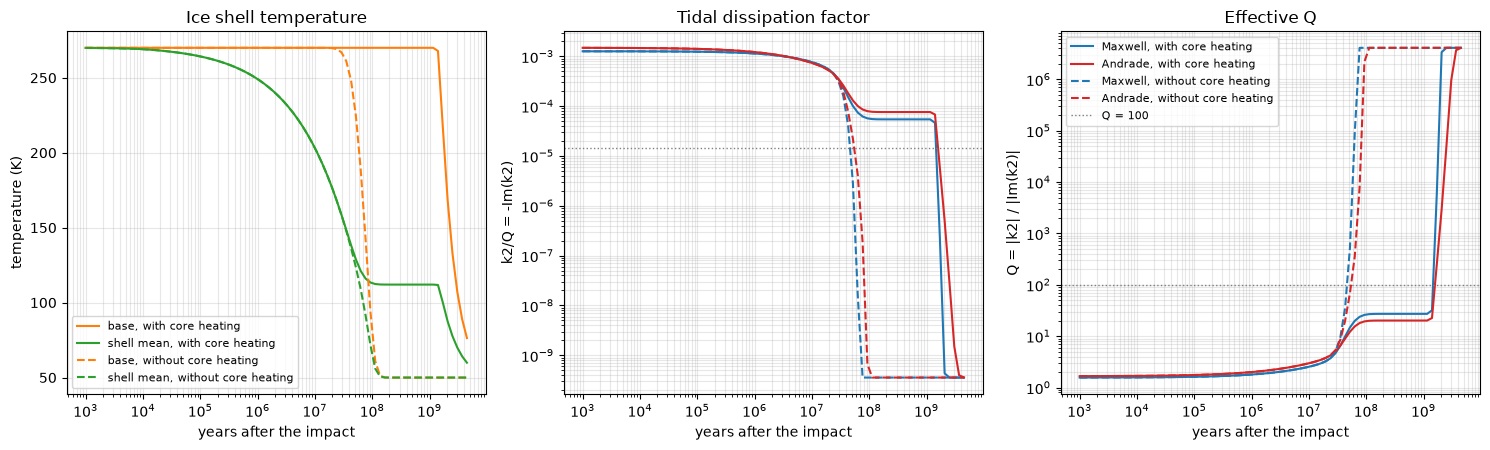

In [5]:
t_years = TIMES[1:] / YEAR
styles = {"with core heating": "-", "without core heating": "--"}
colors = {"Maxwell": "C0", "Andrade": "C3"}
figure, (ax_t, ax_kq, ax_q) = plt.subplots(1, 3, figsize=(15.0, 4.6))

for case, temperature in shell_temperature.items():
    mean = (temperature[:-1] * node_volume[:, None]).sum(axis=0) / node_volume.sum()
    ax_t.semilogx(t_years, temperature[0, 1:], color="C1", ls=styles[case], label=f"base, {case}")
    ax_t.semilogx(t_years, mean[1:], color="C2", ls=styles[case], label=f"shell mean, {case}")
ax_t.set_ylabel("temperature (K)")
ax_t.set_title("Ice shell temperature")

for (case, name), values in k2.items():
    label = f"{name}, {case}"
    ax_kq.loglog(t_years, -values.imag[1:], color=colors[name], ls=styles[case], label=label)
    ax_q.loglog(t_years, (np.abs(values) / np.abs(values.imag))[1:], color=colors[name], ls=styles[case],
                label=label)
k2_today = abs(k2[("with core heating", "Maxwell")][-1])
ax_kq.axhline(k2_today / 100.0, color="0.5", lw=1.0, ls=":", label="Q = 100 (for comparison)")
ax_q.axhline(100.0, color="0.5", lw=1.0, ls=":", label="Q = 100")
ax_kq.set_ylabel("k2/Q = -Im(k2)")
ax_kq.set_title("Tidal dissipation factor")
ax_q.set_ylabel("Q = |k2| / |Im(k2)|")
ax_q.set_title("Effective Q")
for axis in (ax_t, ax_kq, ax_q):
    axis.set_xlabel("years after the impact")
    axis.grid(alpha=0.3, which="both")
ax_t.legend(fontsize=8)
ax_q.legend(fontsize=8)
figure.tight_layout()
plt.show()

The warm shell keeps Q near 1.6 (Maxwell) to 1.7 (Andrade) for the first million years, and Q is still below 5 about 20 million years after the impact. The dissipation collapses once the base of the shell cools below the melting point. Without core heating that happens 40 to 80 million years after the impact: Q passes 100 at about 50 million years and reaches its present value by about 80 million years. Radioactive heat from the core holds the base at the melting point far longer. Q then sits at about 27 (Maxwell) or 20 (Andrade) until about 1.3 billion years, and climbs to its present value over the following 1 to 3 billion years. Both cases end at the same present-day value, which the next section explains.

## Post-impact and present-day values

The table gives both ends of the history. Two further rows show how much the answer leans on the assumptions: today's value with the ice made perfectly elastic (the dissipation that the rock core alone provides), and both ends for other viscosities of ice at the melting point and of the core.

In [6]:
def summary(value):
    return f"k2 = {abs(value):.3e}, k2/Q = {-value.imag:.3e}, Q = {abs(value) / abs(value.imag):.3g}"


for (case, name), values in k2.items():
    print(f"{name:8} {case:21}  post-impact: {summary(values[0])}")
    print(f"{'':8} {'':21}  today:       {summary(values[-1])}")

today_profile = shell_temperature["with core heating"][:, -1]
print("\nToday, elastic ice (core dissipation only):", summary(love_k2(today_profile, Maxwell(), elastic_ice=True)))

print("\nPost-impact Q for other ice viscosities at the melting point:")
for eta_melt in (1.0e13, 1.0e14, 1.0e15):
    values = {name: love_k2(np.full(NODES, T_MELT), rheology, eta_melt=eta_melt)
              for name, rheology in RHEOLOGIES.items()}
    print(f"  {eta_melt:.0e} Pa s: " + ", ".join(f"{name} {summary(v)}" for name, v in values.items()))

print("\nPresent-day Q (with core heating) for other core viscosities:")
for eta_core in (1.0e20, 1.0e22, 1.0e24):
    values = {name: love_k2(today_profile, rheology, eta_core=eta_core) for name, rheology in RHEOLOGIES.items()}
    print(f"  {eta_core:.0e} Pa s: " + ", ".join(f"{name} {summary(v)}" for name, v in values.items()))

Maxwell  with core heating      post-impact: k2 = 1.976e-03, k2/Q = 1.268e-03, Q = 1.56
                                today:       k2 = 1.472e-03, k2/Q = 3.579e-10, Q = 4.11e+06
Andrade  with core heating      post-impact: k2 = 2.472e-03, k2/Q = 1.487e-03, Q = 1.66
                                today:       k2 = 1.472e-03, k2/Q = 3.595e-10, Q = 4.09e+06
Maxwell  without core heating   post-impact: k2 = 1.976e-03, k2/Q = 1.268e-03, Q = 1.56
                                today:       k2 = 1.472e-03, k2/Q = 3.579e-10, Q = 4.11e+06
Andrade  without core heating   post-impact: k2 = 2.472e-03, k2/Q = 1.487e-03, Q = 1.66
                                today:       k2 = 1.472e-03, k2/Q = 3.579e-10, Q = 4.11e+06

Today, elastic ice (core dissipation only): k2 = 1.472e-03, k2/Q = 3.579e-10, Q = 4.11e+06

Post-impact Q for other ice viscosities at the melting point:
  1e+13 Pa s: Maxwell k2 = 1.267e-02, k2/Q = 1.254e-02, Q = 1.01, Andrade k2 = 1.325e-02, k2/Q = 1.296e-02, Q = 1.02
  1e+14 

Right after the impact, with the whole shell at the melting point, Charon's effective Q is about 1.6 with Maxwell ice and 1.7 with Andrade ice, and k2/Q is about 1.3e-3 to 1.5e-3. The ice sits close to its dissipation peak there, so the value depends mainly on the viscosity of ice at the melting point: Q is about 1.0 for 1e13 Pa s and 7 to 11 for 1e15 Pa s.

Today the model gives Q of about 4e6 and k2/Q of about 3.6e-10, but that value says nothing about the ice. The present-day shell is so cold (50 to 76 K) that it responds elastically, and the same value comes out with the ice made perfectly elastic. It is the dissipation of the rock core, and it scales directly with the core viscosity assumed: Q of about 4e4 for 1e20 Pa s and a few hundred million for 1e24 Pa s. A flow-law rheology therefore cannot pin down present-day Charon's Q. Cold ice likely dissipates through mechanisms these flow laws leave out, and tidal-evolution studies of icy bodies commonly adopt a Q of order 100 instead (the dotted lines). Charon's present orbit is also circular and synchronous, so almost no tide is left to dissipate; Q here describes how Charon would respond at its orbital frequency.

Caveats: heat moves only by conduction, although a 150 km shell near the melting point would convect and cool differently; the core's stored heat and the latent heat of melting are ignored, so the base is held at the melting point rather than forming an ocean; and the forcing frequency is today's orbital mean motion throughout, although right after the impact Charon orbited closer and was not yet synchronous, so its early tidal frequencies were higher.